# Spectral Earth Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)


import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra.experimental import initialize, compose
from geofm_src.factory import create_dataset


# Set the config directory for OmegaConf to resolve relative paths
config_dir = 'geofm_src/configs/dataset'
# Note: if you run this multiple times, you need to clear the previous initialization
GlobalHydra.instance().clear()

# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/dataset")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:43: UserWarning: hydra.experimental.initialize() is no longer experimental. Use hydra.initialize()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  self.delegate = real_initialize(


hydra.experimental.initialize()

## Test Channel Sampler

In [8]:

ds_cfg_train = compose(config_name="corine_modis")
ds_cfg_test = compose(config_name="corine_sd")

train_ds, val_ds, test_ds = create_dataset(ds_cfg_train, ds_cfg_test)
print(ds_cfg_train)
print(ds_cfg_test)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/compose.py:25: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'corine_modis': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'corine_sd': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


train_config: {'dataset_type': 'corine', 'task': 'classification', 'num_classes': 19, 'num_channels': 16, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'wavelengths_mean_nm': None, 'wavelengths_sigma_nm': None, 'wavelengths_mean_microns': None, 'multilabel': True, 'image_resolution': 128, 'subset': {'train': -1, 'val': -1, 'test': -1}, 'input_key': None, 'sequence_length': None, 'band_gsds': None, 'scale': 1.0, 'normalize_target': True, 'senpamae_channels': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'band_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'dataset_name': 'spectral_earth', 'full_spectra': True, 'target_dataset_name': 'dummy-modis', 'senpamae_srf_name': 'rfs_modis_terra.npy'}
test_config: {'dataset_type': 'corine', 'task': 'classification', 'num_classes': 19, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'wavelengths_mean_nm': None, 'wavelengths_sigma_nm': None, 'wavelengths_mean_microns': None, 'multilabel': Tru

In [12]:
sample, label = train_ds[11]
sample.shape, label

(torch.Size([16, 128, 128]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]))

In [10]:
sample, label = val_ds[11]
sample.shape, label

(torch.Size([8, 128, 128]),
 tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]))

torch.Size([16, 128, 128]) tensor([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor(-0.7442) tensor(4.3962)


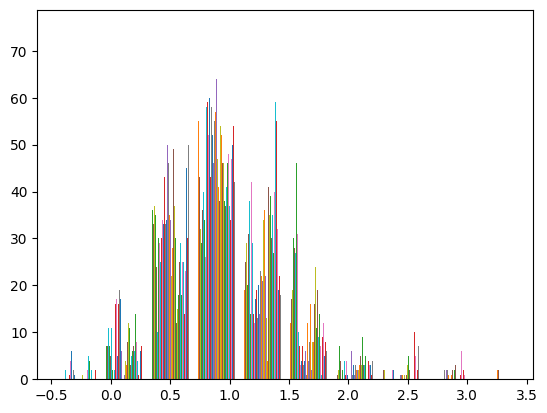

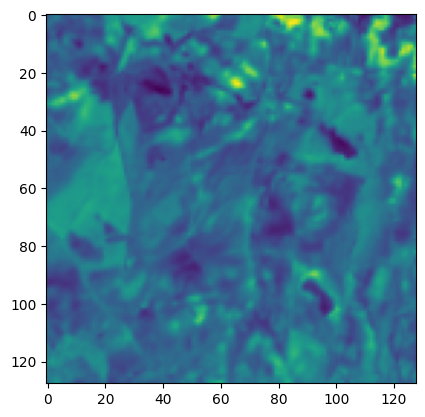

In [13]:
import random
import matplotlib.pyplot as plt
sample, label = train_ds[random.randint(0, len(train_ds))]
print(sample.shape, label)
print(sample.min(), sample.max())

plt.hist(sample[5], bins=10)
plt.show()

plt.imshow(sample[5])
plt.show()


In [36]:
sample, label = test_ds[-1]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]))

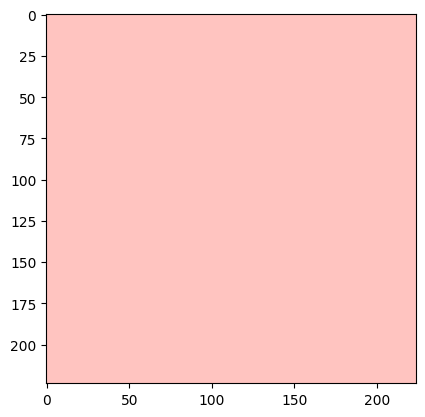

In [37]:
rgb = sample[[5,8,10], :, :]


import matplotlib.pyplot as plt

img = rgb.permute(1, 2, 0).numpy()

img = img - img.min() / (img.max() - img.min())

plt.imshow(img)
plt.show()



# Test channel simulator


Lets use Corine data as input and map it to the Planet SuperDove sensor

In [31]:
import matplotlib.pyplot as plt

def plot_superdove_sensor(sample):

    rgb = sample[[5,3,1], :, :]

    img = rgb.permute(1, 2, 0).numpy()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.show()

In [7]:
from omegaconf import OmegaConf
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/corine_sd.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

[ClsDataAugmentation: train] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])
[ClsDataAugmentation: val/test] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])
{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 128, 'multilabel': True, 'target_dataset_name': 'dummy-superdove', 'band_ids': [0, 1, 2, 3, 4, 5, 6, 7], 'senpamae_srf_name': 'rfs_superdove.npy', 'senpamae_channels': [0, 1, 2, 3, 4, 5, 6, 7], 'band_gsds': [30, 30, 30, 30, 30, 30, 30, 30], 'wavelengths_mean_nm': [443, 490, 532, 565, 611, 665, 706, 864], 'wavelengths_sigma_nm': [7, 20, 14, 15, 

In [8]:
from omegaconf import OmegaConf
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/corine_modis.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print(ds_cfg)

[ClsDataAugmentation: train] Simulating channels: tensor([[ 411,   14],
        [ 442,    8],
        [ 466,   18],
        [ 487,   10],
        [ 529,   10],
        [ 546,   10],
        [ 554,   17],
        [ 644,   34],
        [ 665,   10],
        [ 677,    9],
        [ 746,    9],
        [ 857,   34],
        [ 866,   13],
        [1241,   23],
        [1627,   27],
        [2113,   47]])
[ClsDataAugmentation: val/test] Simulating channels: tensor([[ 411,   14],
        [ 442,    8],
        [ 466,   18],
        [ 487,   10],
        [ 529,   10],
        [ 546,   10],
        [ 554,   17],
        [ 644,   34],
        [ 665,   10],
        [ 677,    9],
        [ 746,    9],
        [ 857,   34],
        [ 866,   13],
        [1241,   23],
        [1627,   27],
        [2113,   47]])
{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 16, 'data_path': '${oc.env:DATASETS_DIR

In [9]:
len(train_ds)

8250

{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 128, 'multilabel': True, 'target_dataset_name': 'dummy-superdove', 'band_ids': [0, 1, 2, 3, 4, 5, 6, 7], 'senpamae_srf_name': 'rfs_superdove.npy', 'senpamae_channels': [0, 1, 2, 3, 4, 5, 6, 7], 'band_gsds': [30, 30, 30, 30, 30, 30, 30, 30], 'wavelengths_mean_nm': [443, 490, 532, 565, 611, 665, 706, 864], 'wavelengths_sigma_nm': [7, 20, 14, 15, 9, 12, 6, 15]}

torch.Size([8, 224, 224]) tensor([0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])


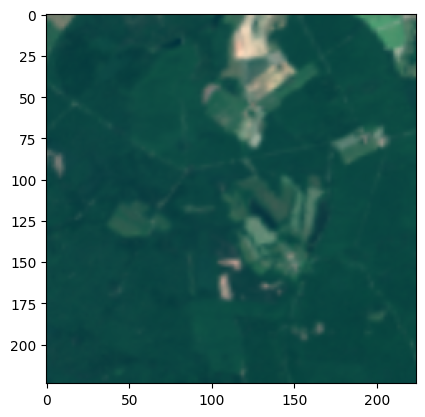

In [40]:
import random
i = random.randint(0, len(train_ds))
sample, label = train_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)

torch.Size([8, 224, 224]) tensor([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])


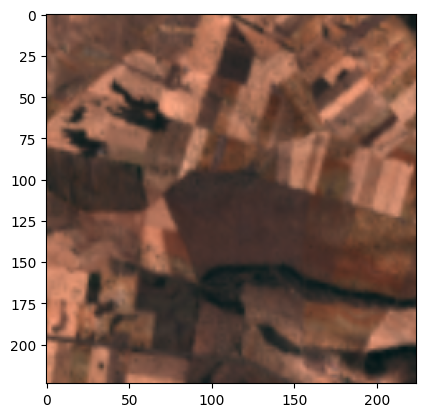

In [39]:
i = random.randint(0, len(val_ds))
sample, label = val_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)

torch.Size([8, 224, 224]) tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0])


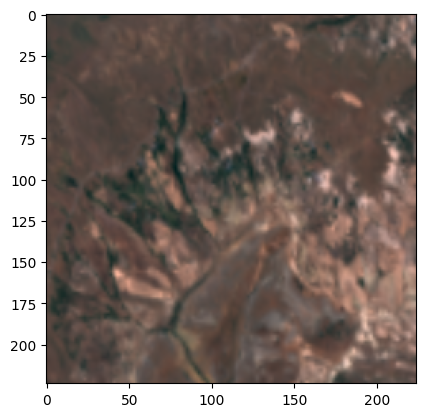

In [38]:
i = random.randint(0, len(test_ds))
sample, label = test_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)


In [41]:
ds_cfg

{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 224, 'multilabel': True, 'full_spectra': True, 'target_dataset_name': 'dummy-superdove', 'wavelengths_mean_nm': [443, 490, 532, 565, 611, 665, 706, 864], 'wavelengths_sigma_nm': [7, 20, 14, 15, 9, 12, 6, 15]}